# GPGN268 - Geophysical Data Analysis
## Data Story 01 - Well Logging

**Student:** Cooper Carlson
**Collaborators:** Blaster the Burro
- Blaster the Burro provided emotional support
**Date:** May the 4th, 2078

# What is well-logging?
Well-logging is a data collection process that involves drilling boreholes into the subsurface and taking depth-dependent measurements. Well-logging data typically has a variety of measurements, all designed to characterize material at a given depth in order to identify spatial variation.

# What data are we using and where did it come from?
The data used in this project comes from the International Ocean Discovery Program Expedition 372A, in which logging-while-drilling was used to drill a borehole in the Tuaheni Landslide Complex (TLC) within the Kihurangi Trough off the east coast of New Zealand's North Island. The TLC exists where the Pacific plate subducts under the Australian plate off the coast, potentially agitating gas hydrates which can lead to subsurface instability. The goal of the project was to identify whether these gas hydrates are present, and whether they are causing the unexpectedly slow, creeping landslide behavior that is seen in the TLC. The well-logging data in the project includes measurements of density and porosity, resistivity, gamma radiation, and sound wave propagation speed. These variables make a composite measurement that can indicate the presence of gas hydrates.

# What are these types of data used for?
Subsurface data can be used for mineral identification, oil and gas testing, subsurface research, geohazard mapping, and more. The individual measurements that a borehole typically takes can be used differently for different tasks.

# What is the format of the data?
Well-logging data is 1D spatial data. Each measurement ranges across depth only throughout the length of the borehole.

# What are some common tools used for analyzing and interpreting this data?
Python packages like pandas and numpy are the most commonly used data analysis tools. I will use pandas for data processing and matplotlib to make figures.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
cali_path = "../ds01-well-log/well-log-data/372-U1517A_cali-nscope.csv"

df_cali = pd.read_csv(
    cali_path,
    skiprows=[0, 1, 2, 3, 5]
)

df_cali.head()

,DEPTH_LSF,UCAV
0,0.1348,8.671005
1,0.2872,8.791258
2,0.4396,9.234136
3,0.5920,9.187814
4,0.7444,8.867629


In [3]:
grma_path = "../ds01-well-log/well-log-data/372-U1517A_gr-nscope.csv"
grab_path = "../ds01-well-log/well-log-data/372-U1517A_gr-gvr.csv"

df_grma = pd.read_csv(
    grma_path,
    skiprows=[0, 1, 2, 3, 5]
)

df_grab = pd.read_csv(
    grab_path,
    skiprows=[0, 1, 2, 3, 5]
)

display(df_grma.head())
display(df_grab.head())
print(df_grma.columns)
print(df_grab.columns)

,DEPTH_LSF,GRMA
0,0.4396,1.550004
1,0.4701,1.891901
2,0.5006,2.233648
3,0.5311,2.575546
4,0.5616,2.917978


,DEPTH_LSF,GR_RAB
0,0.0129,5.399876
1,0.0434,5.944551
2,0.0739,6.488374
3,0.1044,7.031960
4,0.1348,7.575950


Index(['DEPTH_LSF', 'GRMA'], dtype='str')
Index(['DEPTH_LSF', 'GR_RAB'], dtype='str')


In [4]:
import pandas as pd

den_path = "../ds01-well-log/well-log-data/372-U1517A_den-nscope.csv"

df_den = pd.read_csv(
    den_path,
    skiprows=[0, 1, 2, 3, 5]
)

df_den.head()

,DEPTH_LSF,RHON
0,0.1348,1.402081
1,0.2872,1.385705
2,0.4396,1.358488
3,0.5920,1.354235
4,0.7444,1.368756


In [5]:
import pandas as pd

por_path = "../ds01-well-log/well-log-data/372-U1517A_por-nscope.csv"

df_por = pd.read_csv(
    por_path,
    skiprows=[0, 1, 2, 3, 5]
)

df_por.head()

,DEPTH_LSF,BPHI,TNPH
0,0.4396,78.2805,76.5830
1,0.5920,76.7572,73.0690
2,0.7444,82.5710,87.7254
3,0.8968,76.0455,74.5799
4,1.0492,74.2058,73.4775


In [6]:
import pandas as pd

res_gvr_path = "../ds01-well-log/well-log-data/372-U1517A_res-gvr.csv"
res_atten_path = "../ds01-well-log/well-log-data/372-U1517A_res-atten-nscope.csv"
res_phase_path = "../ds01-well-log/well-log-data/372-U1517A_res-phase-nscope.csv"

df_res_gvr = pd.read_csv(
    res_gvr_path,
    skiprows=[0, 1, 2, 3, 5]
)

df_res_atten = pd.read_csv(
    res_atten_path,
    skiprows=[0, 1, 2, 3, 5]
)

df_res_phase = pd.read_csv(
    res_phase_path,
    skiprows=[0, 1, 2, 3, 5]
)

df_res_gvr.head(), df_res_atten.head(), df_res_phase.head()

(   DEPTH_LSF    RES_BD   RES_BIT    RES_BM    RES_BS  RES_RING
 0     0.1348  0.283206  0.462528  0.281343  0.298013  0.287475
 1     0.2872  0.283637  0.516321  0.328798  0.292740  0.264908
 2     0.4396  0.349533  0.508871  0.297567  0.457422  0.357158
 3     0.5920  0.433347  0.715893  0.486653  0.457790  0.454937
 4     0.7444  0.499190  0.705581  0.447070  0.558550  0.531664,
    DEPTH_LSF      A16B      A16H      A16L      A22B      A22H      A22L  \
 0     0.1348  0.586082  0.605559  0.586082  0.599109  0.616815  0.599109   
 1     0.2872  0.621122  0.627951  0.621121  0.634826  0.640407  0.634826   
 2     0.4396  0.657758  0.656639  0.657758  0.671563  0.670512  0.671563   
 3     0.5920  0.689537  0.694921  0.689537  0.705435  0.706657  0.705435   
 4     0.7444  0.719549  0.717992  0.719549  0.738906  0.732580  0.738905   
 
        A28B      A28H      A28L      A34B      A34H      A34L      A40B  \
 0  0.594265  0.620935  0.594265  0.587228  0.620780  0.587228  0.591475   

In [7]:
import pandas as pd

vel_path = "../ds01-well-log/well-log-data/372-U1517A_vel-sscope.csv"

df_vel = pd.read_csv(
    vel_path,
    skiprows=[0, 1, 2, 3, 5]
)

df_vel.head()

,DEPTH_LSF,DTCO,DTSM,VCO,VSH
0,0.0332,206.89297,-999.25.00000,1.4732,-999.25
1,0.1856,207.35735,-999.25.00000,1.4699,-999.25
2,0.3380,208.08044,-999.25.00000,1.4648,-999.25
3,0.4904,208.31265,-999.25.00000,1.4632,-999.25
4,0.6428,208.32063,-999.25.00000,1.4631,-999.25


Text(0.5, 0.98, 'Summary of logs in Hole U1517A - IODP Expedition 372')

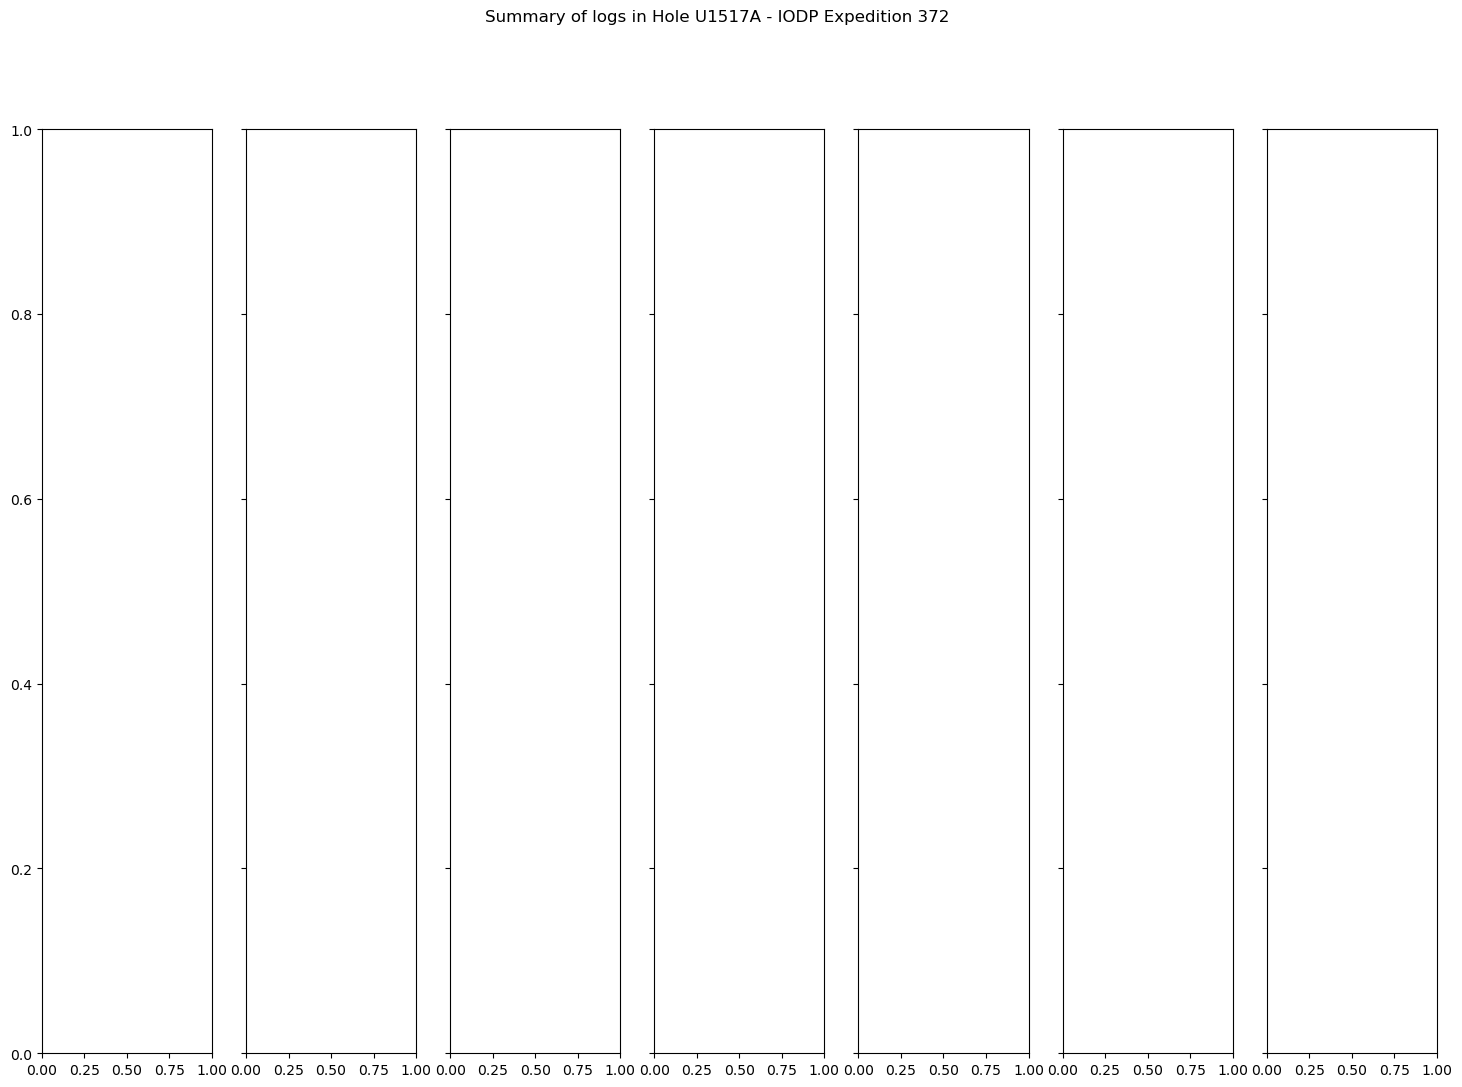

In [8]:
fig_all, axes_all = plt.subplots(
    1, 7,
    figsize=(18, 12),
    sharey=True,
    gridspec_kw={"wspace": 0.2}
)

fig_all.suptitle("Summary of logs in Hole U1517A - IODP Expedition 372")

In [9]:
ax_cali  = axes_all[0]

depth_cali = df_cali["DEPTH_LSF"]
ucav = df_cali["UCAV"]

bit_size = 8
left = -ucav / 2
right = ucav / 2
bit_left = -bit_size / 2
bit_right = bit_size / 2

ax_cali.plot(left, depth_cali, label="UCAV", color="black")
ax_cali.plot(right, depth_cali, color="black")
ax_cali.axvline(bit_left, linestyle="--", label="Bit size", color="black")
ax_cali.axvline(bit_right, linestyle="--", color="black")

ax_cali.set_xlabel("UCAV (NeoScope)")
ax_cali.set_ylabel("Depth (mbsf)")
ax_cali.set_yticks(range(0, 201, 20))

ax_cali.set_xlim(-6.5, 6.5)
ax_cali.set_xticks([-6.5, 6.5])
ax_cali.set_xticklabels(["0", "13"])

ax_cali.xaxis.set_ticks_position("top")
ax_cali.xaxis.set_label_position("top")
ax_cali.set_title("Hole Size (in)")
ax_cali.grid(True, axis="y")

In [10]:
ax_gamma = axes_all[1]

depth_grma = df_grma["DEPTH_LSF"]
grma = df_grma["GRMA"]

depth_grab = df_grab["DEPTH_LSF"]
grab = df_grab["GR_RAB"]

ax_gamma.plot(grma, depth_grma, label="GRMA", color="blue")
ax_gamma.plot(grab, depth_grab, label="GRAB", color="orange")

ax_gamma.set_xlabel("Gamma ray (gAPI)")
ax_gamma.xaxis.set_ticks_position("top")
ax_gamma.xaxis.set_label_position("top")
ax_gamma.set_title("Gamma Ray")
ax_gamma.grid(True, axis="y")
ax_gamma.legend()

In [11]:
ax_den   = axes_all[2]

depth_den = df_den["DEPTH_LSF"]
rhon = df_den["RHON"]

ax_den.plot(rhon, depth_den, color="blue")

ax_den.set_xlim(0.9, 2.1)
ax_den.set_xlabel("RHON (NeoScope)")
ax_den.set_xticks([0.9, 2.1])
ax_den.xaxis.set_ticks_position("top")
ax_den.xaxis.set_label_position("top")
ax_den.set_title("Density")
ax_den.grid(True, axis="y")

In [12]:
ax_por = axes_all[3]

depth_por = df_por["DEPTH_LSF"]
bphi = df_por["BPHI"]
tnph = df_por["TNPH"]

ax_por.plot(bphi, depth_por, color="blue", label="BPHI")
ax_por.plot(tnph, depth_por, color="deepskyblue", label="TNPH")

ax_por.set_xlim(30, 100)
ax_por.set_xticks([30, 100])
ax_por.xaxis.set_ticks_position("top")
ax_por.xaxis.set_label_position("top")
ax_por.set_title("Porosity (%)")
ax_por.grid(True, axis="y")
ax_por.legend()

In [13]:
depth_res_gvr = df_res_gvr["DEPTH_LSF"]
res_bd = df_res_gvr["RES_BD"]

depth_res_atten = df_res_atten["DEPTH_LSF"]
a40b = df_res_atten["A40B"]

depth_res_phase = df_res_phase["DEPTH_LSF"]
p16b = df_res_phase["P16B"]

ax_res = axes_all[4]

ax_res.plot(res_bd, depth_res_gvr, color="red", label="RES_BD (deep)")
ax_res.plot(a40b, depth_res_atten, color="green", label="A40B (medium)")
ax_res.plot(p16b, depth_res_phase, color="blue", label="P16B (shallow)")

ax_res.set_xscale("log")
ax_res.set_xlim(0.2, 20)
ax_res.set_xticks([0.2, 20])
ax_res.set_xticklabels(["0.2", "20"])
ax_res.xaxis.set_ticks_position("top")
ax_res.xaxis.set_label_position("top")
ax_res.set_title("Resistivity (ohm.m)")
ax_res.grid(True, axis="x", which="both", alpha=1)
ax_res.legend()

In [14]:
depth_vp = df_vel["DEPTH_LSF"]
vp = df_vel["VCO"] * 1000

ax_vp = axes_all[5]

ax_vp.plot(vp, depth_vp, color="black")

ax_vp.set_xlim(1450, 1950)
ax_vp.set_xticks([1450, 1950])
ax_vp.xaxis.set_ticks_position("top")
ax_vp.xaxis.set_label_position("top")
ax_vp.set_title("Vp (monopole) (m/s)")
ax_vp.grid(True, axis="y")

In [15]:
depth_vs = df_vel["DEPTH_LSF"]
vs = df_vel["VSH"] * 1000

ax_vs = axes_all[6]

ax_vs.plot(vs, depth_vs, color="black")

ax_vs.set_xlim(340, 480)
ax_vs.set_xticks([340, 480])
ax_vs.xaxis.set_ticks_position("top")
ax_vs.xaxis.set_label_position("top")
ax_vs.set_title("Vs (SonicScope) (m/s)")
ax_vs.grid(True, axis="y")

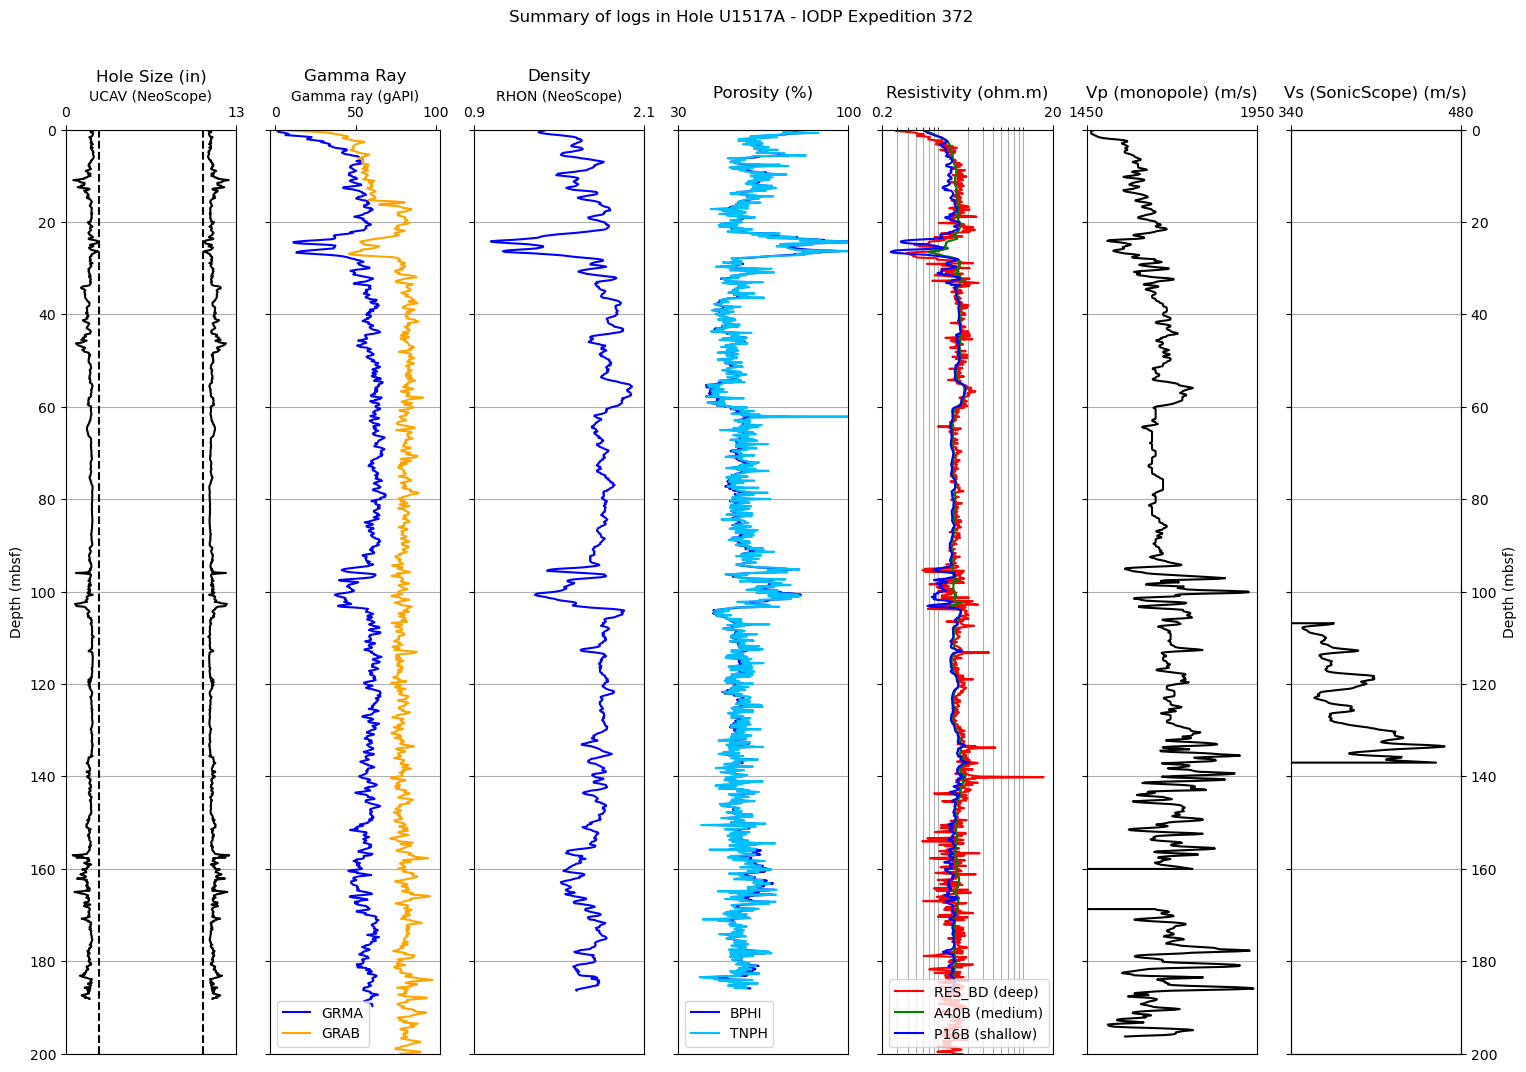

<Figure size 640x480 with 0 Axes>

In [16]:
for ax in axes_all:
    ax.set_ylim(200, 0)

ax_right = axes_all[-1].twinx()
ax_right.set_ylim(axes_all[0].get_ylim())
ax_right.set_yticks(axes_all[0].get_yticks())
ax_right.set_ylabel("Depth (mbsf)")

plt.tight_layout()
display(fig_all)

## Observations and conclusions

There is significant spatial variation in every single measurement. This indicates that the subsurface is not uniform, and there are different effects dominating at different depths.

Spikes in one plot usually correlate with spikes in another plot at the same depth. For example, GRMA, density, porosity, resistivity, and Vp all have significant disturbances around 100 mbsf. This could mark the presence of gas hydrates, or it could mean something else. Most likely, there is something significant happening at that depth.

Density and porosity are strongly inversely correlated throughout the entire well. This makes sense based on the definitions of density and porosity.

GRMA and GRAB spikes do not always occur in the same place. I have no idea what this could mean.

I suspect there are gas hydrates present at 100 mbsf, due to the sudden increase in porosity as well as the drop in GRMA and resistivity. I also drew this conclusion because that's the conclusion that the researchers who actually did this analysis drew. They point to resistivity anomalies around 110-150 mbsf as indications of this.